In [1]:
import pandas as pd
import numpy as np

In [2]:
data_url = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
df = pd.read_csv(data_url)

In [3]:
df = pd.read_csv(data_url)

In [4]:
df.head(2)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650


In [5]:
df.columns = df.columns.str.lower().str.replace(" ","_")

In [6]:
string_columns = list(df.dtypes[df.dtypes == 'str'].index)
print(string_columns)

['make', 'model', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']


In [7]:
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(" ", "_")

In [8]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [9]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


# 2.03 Exploratory Data Analysis

In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5].tolist())
    print(df[col].nunique())
    print()

make
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
48

model
['1_series_m', '1_series', '100', '124_spider', '190-class']
914

year
[2011, 2012, 2013, 1992, 1993]
28

engine_fuel_type
['premium_unleaded_(required)', 'regular_unleaded', 'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)', 'diesel']
10

engine_hp
[335.0, 300.0, 230.0, 320.0, 172.0]
356

engine_cylinders
[6.0, 4.0, 5.0, 8.0, 12.0]
9

transmission_type
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
5

driven_wheels
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive', 'four_wheel_drive']
4

number_of_doors
[2.0, 4.0, 3.0, nan]
3

market_category
['factory_tuner,luxury,high-performance', 'luxury,performance', 'luxury,high-performance', 'luxury', 'performance']
71

vehicle_size
['compact', 'midsize', 'large']
3

vehicle_style
['coupe', 'convertible', 'sedan', 'wagon', '4dr_hatchback']
16

highway_mpg
[26, 28, 27, 25, 24]
59

city_mpg
[19, 20, 18, 17, 16]
69

popularity
[3916, 31

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

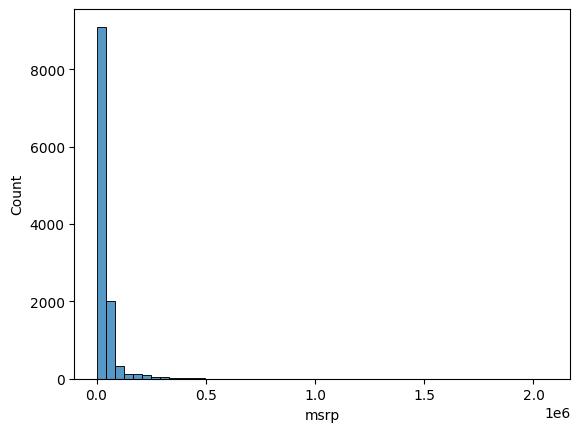

In [12]:
sns.histplot(df['msrp'], bins=50);

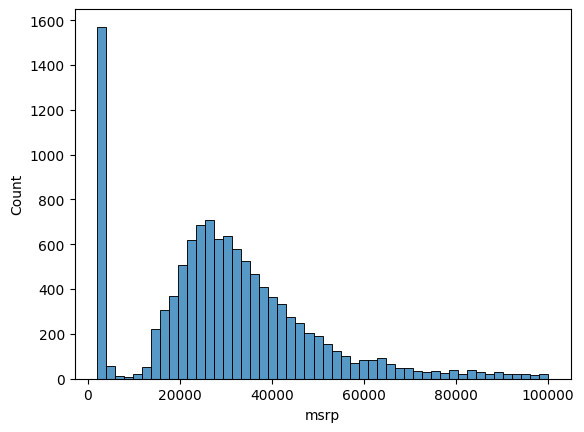

In [13]:
sns.histplot(df['msrp'][df['msrp']<100_000], bins=50);

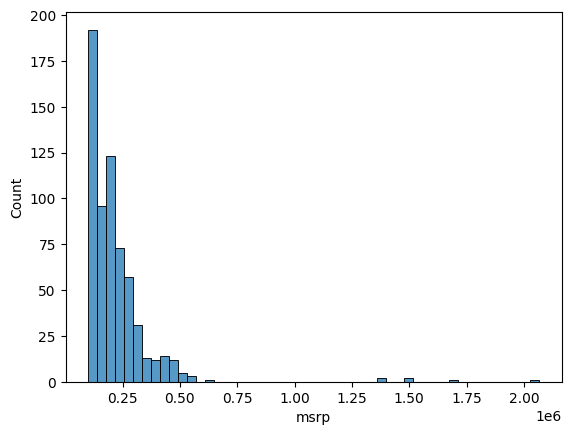

In [14]:
sns.histplot(df['msrp'][df['msrp']>=100_000], bins=50);

In [15]:
price_logs = np.log1p(df['msrp'])

<Axes: xlabel='msrp', ylabel='Count'>

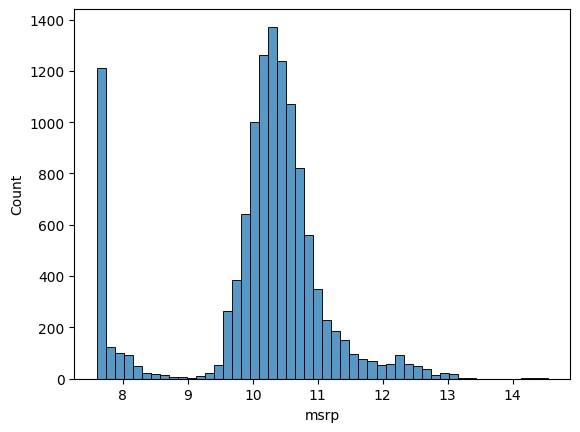

In [16]:
sns.histplot(price_logs, bins=50)

In [17]:
df.isna().sum(axis=0)

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## 2.04 Setting up the validation framework

In [18]:
n_val = int(len(df) * 0.2)
n_test = int(len(df) * 0.2)
n_train = int(len(df) - n_val - n_test)

In [19]:
n_train, n_val, n_test

(7150, 2382, 2382)

In [20]:
idx = np.arange(len(df))

In [21]:
np.random.seed(2)
np.random.shuffle(idx)

In [22]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [23]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [24]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [25]:
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

In [26]:
y_train = np.log1p(df_train['msrp'].values)
y_val = np.log1p(df_val['msrp'].values)
y_test = np.log1p(df_test['msrp'].values)

del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

## 2.05 - Linear regression

In [27]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [28]:
xi = [453, 11, 86]

In [29]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [30]:
def linear_regression(xi):
    n = len(xi)
    y_hat = w0

    for j in range(n):
        y_hat += w[j]*xi[j]
    
    return y_hat

In [31]:
linear_regression(xi)

12.312

In [32]:
np.expm1(12.312)

np.float64(222347.2221101062)

## 2.06 Linear regression in vector form

In [33]:
def dot(xi, w):
    n = len(xi)

    result = 0
    for j in range(n):
        result += xi[j]*w[j]
    
    return result

In [34]:
def linear_regression(xi):
    xi = [1] + xi
    pred = dot(xi, w_new)
    return pred

In [35]:
w_new = [w0] + w
w_new

[7.17, 0.01, 0.04, 0.002]

In [36]:
linear_regression(xi)

12.312

In [37]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [38]:
x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x3 = [1, 453, 11, 86]

x = [x1, x2, x3]
x = np.array(x)
x

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [39]:
x.dot(w_new)

array([12.38 , 13.552, 12.312])

In [40]:
def linear_regression(x):
    return x.dot(w_new)

In [41]:
linear_regression(x)

array([12.38 , 13.552, 12.312])

## 2.07 Training a linear regression model

In [42]:
def train_linear_regression(X,y):
    pass

In [43]:
x1 = [148, 24, 1385]
x2 = [132, 25, 2031]
x3 = [453, 11, 86]
x4 = [129, 17, 190]
x5 = [188, 29,2000]

x = [x1, x2, x3, x4, x5]
X = np.array(x)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 129,   17,  190],
       [ 188,   29, 2000]])

In [44]:
xtx = X.T.dot(X)

In [45]:
xtx_inv = np.linalg.inv(xtx)

In [46]:
y = [100, 200, 150, 250, 100,]
xtx_inv.dot(X.T).dot(y)

array([ 0.02388768, 13.15157158, -0.11295487])

In [47]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full

In [48]:
train_linear_regression(X,y)

array([ 6.13656848e+02, -5.72638382e-01, -1.89390733e+01,  5.98256901e-02])

## 2.08 Car price baseline model

In [49]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [50]:
numeric_columns = df_train.columns[(df_train.dtypes == "int64") | (df_train.dtypes == "float64")].tolist()
print(numeric_columns)

['year', 'engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'city_mpg', 'popularity']


In [51]:
X_train = df_train[numeric_columns].fillna(0).values

In [52]:
w_whole = train_linear_regression(X_train, y_train)
w0, w = w_whole[0], w_whole[1:]

In [53]:
y_pred = X_train.dot(w) + w0

<Axes: ylabel='Count'>

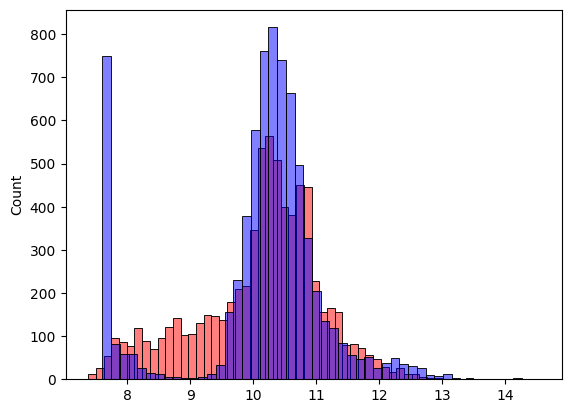

In [54]:
sns.histplot(y_pred, color='red', bins=50, alpha=0.5)
sns.histplot(y_train, color='blue', bins=50, alpha=0.5)

## 2.9 RMSE

In [55]:
def RMSE(y_hat, y):
    error = y_hat - y
    se = error ** 2
    mse = se.mean()
    rmse = np.sqrt(mse)
    return rmse

In [56]:
RMSE(y_pred,y_train)

np.float64(0.5171356682812321)

## 2.10 Computing RMSE on validation data

In [57]:
def prepare_X(df):
    numeric_columns = df.columns[(df.dtypes == "int64") | (df.dtypes == "float64")].tolist()
    X = df[numeric_columns].fillna(0).values
    return X

In [58]:
X_val = prepare_X(df_val)

In [59]:
y_hat_val = w0 + X_val.dot(w)

In [60]:
y_val.shape

(2382,)

In [61]:
RMSE(y_hat = y_hat_val, y = y_val)

np.float64(0.5168234951466537)

## 2.11 Feature engineering

In [64]:
df_train.year.max() - df_train.year

0        9
1        5
2        1
3       26
4        0
        ..
7145     2
7146     2
7147     2
7148     3
7149     0
Name: year, Length: 7150, dtype: int64

In [98]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = df.year.max() - df.year
    df.drop(columns='year', inplace=True)
    numeric_columns = df.columns[(df.dtypes == "int64") | (df.dtypes == "float64")].tolist()
    print(numeric_columns)
    X = df[numeric_columns].fillna(0).values
    return X

In [99]:
prepare_X(df_train)

['engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'city_mpg', 'popularity', 'age']


array([[1.480e+02, 4.000e+00, 2.000e+00, ..., 2.400e+01, 1.385e+03,
        9.000e+00],
       [1.320e+02, 4.000e+00, 4.000e+00, ..., 2.500e+01, 2.031e+03,
        5.000e+00],
       [1.480e+02, 4.000e+00, 4.000e+00, ..., 2.800e+01, 6.400e+02,
        1.000e+00],
       ...,
       [2.850e+02, 6.000e+00, 4.000e+00, ..., 1.700e+01, 5.490e+02,
        2.000e+00],
       [5.630e+02, 1.200e+01, 4.000e+00, ..., 1.300e+01, 8.600e+01,
        3.000e+00],
       [2.000e+02, 4.000e+00, 4.000e+00, ..., 2.200e+01, 8.730e+02,
        0.000e+00]], shape=(7150, 7))

In [100]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [101]:
X_train = prepare_X(df_train)
w_total = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w_total[0] + X_val.dot(w_total[1:])
RMSE(y_val, y_pred)

['engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'city_mpg', 'popularity', 'age']
['engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'city_mpg', 'popularity', 'age']


np.float64(0.5168234951483387)

<Axes: ylabel='Count'>

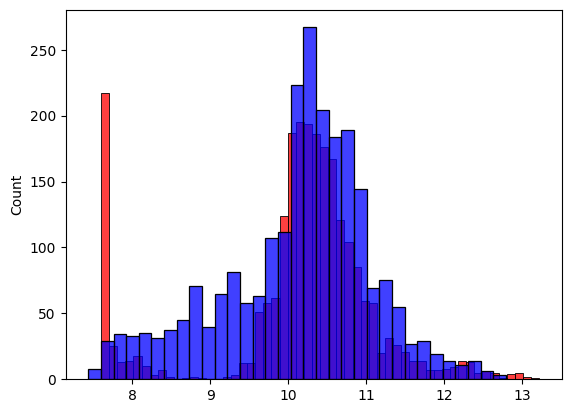

In [103]:
sns.histplot(y_val, color='red')
sns.histplot(y_pred, color='blue')

## 2.12 Categorial Variables

In [105]:
df_train.number_of_doors

0       2.0
1       4.0
2       4.0
3       3.0
4       4.0
       ... 
7145    2.0
7146    2.0
7147    4.0
7148    4.0
7149    4.0
Name: number_of_doors, Length: 7150, dtype: float64

In [120]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = df.year.max() - df.year
    df.drop(columns='year', inplace=True)

    for v in [2, 3, 4]:
        df[f'num_doors_{v}'] = (df.number_of_doors == v).astype('int')
    df.drop(columns="number_of_doors", inplace=True)

    numeric_columns = df.columns[(df.dtypes == "int64") | (df.dtypes == "float64")].tolist()
    print(numeric_columns)
    X = df[numeric_columns].fillna(0).values
    return X



In [121]:
X_train = prepare_X(df_train)
w_total = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w_total[0] + X_val.dot(w_total[1:])
RMSE(y_val, y_pred)

['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity', 'age', 'num_doors_2', 'num_doors_3', 'num_doors_4']
['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity', 'age', 'num_doors_2', 'num_doors_3', 'num_doors_4']


np.float64(0.5157995641501902)

In [129]:
df.make.value_counts().head().index.tolist()

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [143]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = df.year.max() - df.year
    df.drop(columns='year', inplace=True)

    for v in [2, 3, 4]:
        df[f'num_doors_{v}'] = (df.number_of_doors == v).astype('int')
    df.drop(columns="number_of_doors", inplace=True)

    nr_of_top_makes = 10
    makes_list = df.make.value_counts().head(nr_of_top_makes).index.tolist()

    for v in makes_list:
        df[f'make_is_{v}'] = (df.make == v).astype('int')

    numeric_columns = df.columns[(df.dtypes == "int64") | (df.dtypes == "float64")].tolist()
    print(numeric_columns)
    X = df[numeric_columns].fillna(0).values
    return X



In [144]:
X_train = prepare_X(df_train)
w_total = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w_total[0] + X_val.dot(w_total[1:])
RMSE(y_val, y_pred)

['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity', 'age', 'num_doors_2', 'num_doors_3', 'num_doors_4', 'make_is_chevrolet', 'make_is_ford', 'make_is_volkswagen', 'make_is_toyota', 'make_is_dodge', 'make_is_nissan', 'make_is_gmc', 'make_is_mazda', 'make_is_cadillac', 'make_is_honda']
['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity', 'age', 'num_doors_2', 'num_doors_3', 'num_doors_4', 'make_is_chevrolet', 'make_is_ford', 'make_is_volkswagen', 'make_is_toyota', 'make_is_dodge', 'make_is_nissan', 'make_is_gmc', 'make_is_honda', 'make_is_suzuki', 'make_is_cadillac']


np.float64(0.503066964426445)

In [145]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [149]:
categories_list = ['make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
                 'market_category','vehicle_size','vehicle_style']

In [ ]:
categories = {}
for c in categories_list:
    categories[c] = df[c].value_counts().head().index.tolist()

In [154]:
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [173]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = df.year.max() - df.year
    df.drop(columns='year', inplace=True)

    for v in [2, 3, 4]:
        df[f'num_doors_{v}'] = (df.number_of_doors == v).astype('int')
    df.drop(columns="number_of_doors", inplace=True)

    categories_list = ['make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
                 'market_category','vehicle_size','vehicle_style']
    categories = {}
    for c in categories_list:
        categories[c] = df[c].value_counts().head().index.tolist()

    for c in categories:
        for v in categories[c]:
            df[f'{c}_is_{v}'] = (df[c] == v).astype('int')

    numeric_columns = df.columns[(df.dtypes == "int64") | (df.dtypes == "float64")].tolist()
   # print(numeric_columns)
    X = df[numeric_columns].fillna(0).values
    return X



In [157]:
X_train = prepare_X(df_train)
w_total = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w_total[0] + X_val.dot(w_total[1:])
RMSE(y_val, y_pred)

['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity', 'age', 'num_doors_2', 'num_doors_3', 'num_doors_4', 'make_is_chevrolet', 'make_is_ford', 'make_is_volkswagen', 'make_is_toyota', 'make_is_dodge', 'engine_fuel_type_is_regular_unleaded', 'engine_fuel_type_is_premium_unleaded_(required)', 'engine_fuel_type_is_premium_unleaded_(recommended)', 'engine_fuel_type_is_flex-fuel_(unleaded/e85)', 'engine_fuel_type_is_diesel', 'transmission_type_is_automatic', 'transmission_type_is_manual', 'transmission_type_is_automated_manual', 'transmission_type_is_direct_drive', 'transmission_type_is_unknown', 'driven_wheels_is_front_wheel_drive', 'driven_wheels_is_rear_wheel_drive', 'driven_wheels_is_all_wheel_drive', 'driven_wheels_is_four_wheel_drive', 'market_category_is_crossover', 'market_category_is_flex_fuel', 'market_category_is_luxury', 'market_category_is_hatchback', 'market_category_is_luxury,performance', 'vehicle_size_is_compact', 'vehicle_size_is_midsize', 'vehicle_size

np.float64(28.476763642856454)

## 2.13 Regularisation

In [165]:
def train_linear_regression(X,y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX += r*np.eye(*XTX.shape)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full

In [169]:
X_train = prepare_X(df_train)
w_total = train_linear_regression(X_train, y_train, r=0.0001)
X_val = prepare_X(df_val)
y_pred = w_total[0] + X_val.dot(w_total[1:])
RMSE(y_val, y_pred)

['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity', 'age', 'num_doors_2', 'num_doors_3', 'num_doors_4', 'make_is_chevrolet', 'make_is_ford', 'make_is_volkswagen', 'make_is_toyota', 'make_is_dodge', 'engine_fuel_type_is_regular_unleaded', 'engine_fuel_type_is_premium_unleaded_(required)', 'engine_fuel_type_is_premium_unleaded_(recommended)', 'engine_fuel_type_is_flex-fuel_(unleaded/e85)', 'engine_fuel_type_is_diesel', 'transmission_type_is_automatic', 'transmission_type_is_manual', 'transmission_type_is_automated_manual', 'transmission_type_is_direct_drive', 'transmission_type_is_unknown', 'driven_wheels_is_front_wheel_drive', 'driven_wheels_is_rear_wheel_drive', 'driven_wheels_is_all_wheel_drive', 'driven_wheels_is_four_wheel_drive', 'market_category_is_crossover', 'market_category_is_flex_fuel', 'market_category_is_luxury', 'market_category_is_hatchback', 'market_category_is_luxury,performance', 'vehicle_size_is_compact', 'vehicle_size_is_midsize', 'vehicle_size

np.float64(0.4764906055814989)

<Axes: ylabel='Count'>

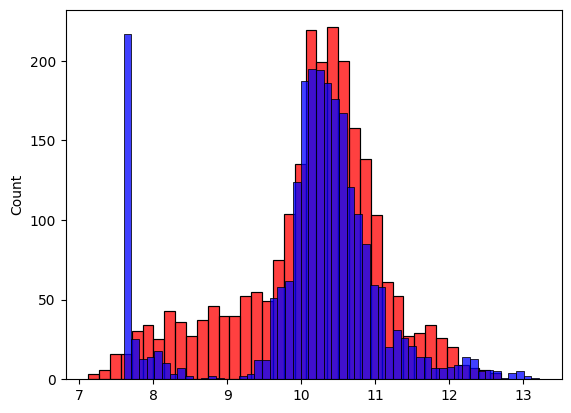

In [170]:
sns.histplot(y_pred, color='red')
sns.histplot(y_val, color='blue')

## 2.14 Tuning the model

In [ ]:
for r in [0, 1e-6, 1e-5, 1e-4, 1e-3,1e-2, 1e-1, 1e1,1e2]:
    X_train = prepare_X(df_train)
    w_total = train_linear_regression(X_train, y_train, r=r)
    X_val = prepare_X(df_val)
    y_pred = w_total[0] + X_val.dot(w_total[1:])
    print(f"r={r}, w0 = {w_total[0]}, RMSE={RMSE(y_val, y_pred)}")


r=0, w0 = -2577834190335544.0, RMSE=28.476763642856454
r=1e-06, w0 = 8.946853072868418, RMSE=0.47649057508192266
r=1e-05, w0 = 7.0900029899944315, RMSE=0.47649046046770904
r=0.0001, w0 = 6.299215543191236, RMSE=0.4764906055814989
r=0.001, w0 = 6.286039235250088, RMSE=0.4764923843021818
r=0.01, w0 = 6.276606574213222, RMSE=0.4765101458424957
r=0.1, w0 = 6.191208702212858, RMSE=0.47668734575631416
r=10.0, w0 = 4.283980108967508, RMSE=0.4963087124468162
r=100.0, w0 = 2.499047083001267, RMSE=0.6040298302300701


In [176]:
r = 0.001

X_train = prepare_X(df_train)
w_total = train_linear_regression(X_train, y_train, r=r)
X_val = prepare_X(df_val)
y_pred = w_total[0] + X_val.dot(w_total[1:])
print(f"r={r}, w0 = {w_total[0]}, RMSE={RMSE(y_val, y_pred)}")


r=0.001, w0 = 6.286039235250088, RMSE=0.4764923843021818
